In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
column_names = ['user_id', 'item_id', 'rating', 'timestamp']

data = pd.read_csv('u.data', sep='\t', names=column_names)

In [ ]:
data.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
data.shape

(100000, 4)

In [ ]:
data.user_id.unique().shape

(943,)

In [ ]:
data.item_id.unique().shape

(1682,)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [ ]:
data.isnull().sum()

,0
user_id,0
item_id,0
rating,0
timestamp,0


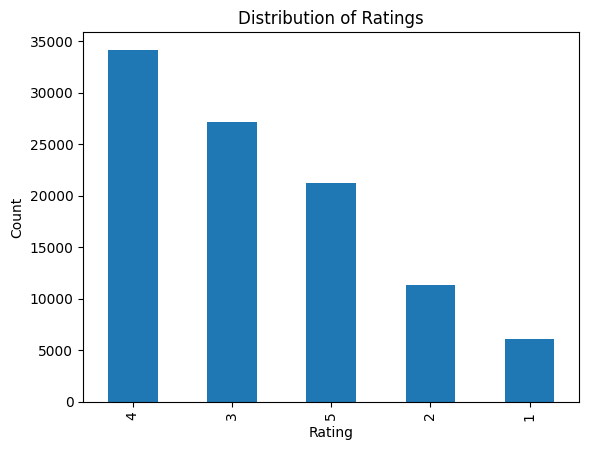

In [ ]:
data.rating.value_counts().plot(kind='bar')
plt.ylabel('Count')
plt.xlabel('Rating')
plt.title('Distribution of Ratings')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2,random_state=42)

In [ ]:
# Build the user-item matrix A from training data.
n_users = data['user_id'].max()
n_items = data['item_id'].max()

In [ ]:
user_ratings = {u: [] for u in range(n_users)}
item_ratings = {j: [] for j in range(n_items)}

In [ ]:
for row in train.itertuples():
  # Convert to 0-index
  user = row.user_id- 1
  item = row.item_id- 1
  rating = row.rating
  user_ratings[user].append((item, rating))
  item_ratings[item].append((user, rating))

In [ ]:
for i in range(3):
  print(f'User {i}: Movie Rating (movie,rating): {user_ratings[i]}')

User 0: Movie Rating (movie,rating): [(82, 3), (35, 2), (29, 3), (167, 5), (150, 4), (52, 3), (215, 5), (60, 4), (69, 3), (9, 3), (43, 5), (163, 3), (70, 3), (115, 3), (32, 4), (2, 4), (188, 3), (210, 3), (259, 1), (268, 5), (175, 5), (90, 5), (168, 5), (46, 4), (164, 5), (44, 5), (123, 5), (56, 5), (199, 3), (265, 1), (230, 1), (41, 5), (6, 4), (68, 3), (186, 4), (153, 5), (15, 5), (127, 4), (193, 4), (170, 5), (208, 4), (86, 5), (134, 4), (74, 4), (227, 5), (200, 3), (49, 5), (103, 1), (47, 5), (73, 1), (34, 1), (184, 4), (147, 2), (207, 5), (177, 5), (225, 3), (249, 4), (171, 5), (104, 2), (91, 3), (11, 5), (239, 3), (222, 5), (218, 1), (144, 2), (138, 3), (165, 5), (108, 5), (224, 2), (13, 5), (61, 3), (88, 5), (84, 3), (64, 4), (106, 4), (228, 4), (233, 4), (243, 2), (139, 1), (80, 5), (252, 5), (211, 4), (214, 3), (72, 3), (18, 5), (66, 3), (161, 4), (96, 3), (271, 3), (190, 5), (231, 3), (172, 5), (89, 4), (137, 1), (51, 4), (112, 5), (126, 5), (21, 4), (178, 3), (48, 3), (151, 

In [ ]:
# ALS hyperparameters
k = 19                # no. of latent features
lambda_reg = 0.1      # regularization parameter
n_iters = 100         # number of iterations

In [ ]:
# Initialize user and item feature matrices randomly between 1 and 5
np.random.seed(20)
U = np.random.uniform(low=1.0, high=5.0, size=(n_users, k))
I = np.random.uniform(low=1.0, high=5.0, size=(n_items, k))

Formulae:

$ I_j = (\Sigma u u^T +\lambda \mathcal{I_k})^{-1}(\Sigma u \space a_{ij}) $

$ U_j = (\Sigma i i^T +\lambda \mathcal{I_k})^{-1}(\Sigma i\space a_{ij}) $

In [ ]:
# ALS iterations
for iteration in range(n_iters):
  # Fix I solve U
  for u in range(n_users):
    items_rated = user_ratings[u]
    if not items_rated:
      continue
    A = np.zeros((k, k))
    b = np.zeros(k)
    for (j, rating) in items_rated:
      I_j = I[j]
      A += np.outer(I_j, I_j)
      b += I_j * rating
    A += lambda_reg * np.eye(k)
    U[u] = np.linalg.solve(A, b)
  # Fix U solve I
  for j in range(n_items):
    users_rated = item_ratings[j]
    if not users_rated:
      continue
    A = np.zeros((k, k))
    b = np.zeros(k)
    for (u, rating) in users_rated:
      U_u = U[u]
      A += np.outer(U_u, U_u)
      b += U_u * rating
    A += lambda_reg * np.eye(k)
    I[j] = np.linalg.solve(A, b)

In [ ]:
# Compute the predicted rating matrix
predicted_matrix = np.dot(U, I.T)

In [ ]:
predicted_matrix.shape

(943, 1682)

In [ ]:
# Model Evaluation
y_true = []
y_pred = []
for row in test.itertuples():
  u = row.user_id- 1
  j = row.item_id- 1
  y_true.append(row.rating)
  y_pred.append(predicted_matrix[u][j])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

In [ ]:
print(f"ALS(k={k}, lambda={lambda_reg}, iterations={n_iters}):")
print(f"RMSE:{rmse:.4f}")
print(f"MAE:{mae:.4f}")

ALS(k=19, lambda=0.1, iterations=100):
RMSE:1.5619
MAE:1.1049


In [ ]:
user_id = 3
movie_id = 335
predicted_rating_user3_movie58 = predicted_matrix[user_id- 1, movie_id- 1]
print(f"Predicted rating for user {user_id} on movie {movie_id}: {predicted_rating_user3_movie58:.4f}")


Predicted rating for user 3 on movie 335: 1.0362


In [ ]:
data[(data['user_id']==3) & (data['item_id']==335)]

,user_id,item_id,rating,timestamp
1257,3,335,1,889237269


In [ ]:
# Movies by name dataset
movie_data=pd.read_csv('u.item', sep='|', encoding='latin1',header=None)

In [ ]:
movie_data.rename(columns={0:'movie_id',1:'movie_title'},inplace=True)

In [ ]:
movie_data.head()

,movie_id,movie_title,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Sample input
user_id = int(input('User ID: '))
list(movie_data.loc[movie_data['movie_id'].isin(np.where(predicted_matrix[user_id - 1]>=4)[0]+1)]['movie_title'])

User ID: 40


['GoldenEye (1995)',
 'Four Rooms (1995)',
 'Babe (1995)',
 'From Dusk Till Dawn (1996)',
 'Taxi Driver (1976)',
 'Bad Boys (1995)',
 'Apollo 13 (1995)',
 'Crimson Tide (1995)',
 'Crumb (1994)',
 'Net, The (1995)',
 'Strange Days (1995)',
 'Billy Madison (1995)',
 'Clerks (1994)',
 'Disclosure (1994)',
 'Ed Wood (1994)',
 'Hoop Dreams (1994)',
 'I.Q. (1994)',
 'Madness of King George, The (1994)',
 'Outbreak (1995)',
 'Pulp Fiction (1994)',
 'Stargate (1994)',
 'Ace Ventura: Pet Detective (1994)',
 'Forrest Gump (1994)',
 'Maverick (1994)',
 "Carlito's Way (1993)",
 'Firm, The (1993)',
 'Fugitive, The (1993)',
 'Jurassic Park (1993)',
 'Remains of the Day, The (1993)',
 'Searching for Bobby Fischer (1993)',
 'Home Alone (1990)',
 'Dances with Wolves (1990)',
 'Silence of the Lambs, The (1991)',
 'Snow White and the Seven Dwarfs (1937)',
 'Heavy Metal (1981)',
 'All Dogs Go to Heaven 2 (1996)',
 'Diabolique (1996)',
 'Flipper (1996)',
 'Wallace & Gromit: The Best of Aardman Animation (1